<div align="center">

![LogoCuc](..\docs\images\b-n-logocuc.png)
</div>

<div align="center">
  
  
### Colegio Universitario de Cartago
#### Carrera de Big Data

#### Programación II
#### Proyecto #2: FIFA World Cup

#### Estudiantes:
#### Sebastián Calvo Solano
#### Isaac Rodríguez Zuñiga

### Profesor: Osvaldo González Chaves

</div>

  



In [1]:
import sys
from pathlib import Path

import pandas as pd

raiz_proyecto = Path(Path.cwd()).parent
sys.path.append(str(raiz_proyecto))

from src.ingesta.CargadorDatos import CargadorDatos
from src.gestor.GestorPartidos import GestorPartidos
from src.eda.EDA import ProcesadorEDA 


In [2]:
cargador = CargadorDatos(
    url_source="https://raw.githubusercontent.com/martj42/international_results/master/results.csv",
    raw_path="../data/raw",
    processed_path="../data/processed"
)
df_raw = cargador.ejecutar()
gestor = GestorPartidos(df_raw)
df_eda = ProcesadorEDA(gestor)

INFO:src.ingesta.CargadorDatos:Descargando CSV desde https://raw.githubusercontent.com/martj42/international_results/master/results.csv
INFO:src.ingesta.CargadorDatos:Descarga completa, dimension de: 49520 filas y 9 columnas
INFO:src.ingesta.CargadorDatos:Filtro aplicado para 'FIFA World Cup': 1068 filas
INFO:src.ingesta.CargadorDatos:Guardado raw en: ..\data\raw\raw_results.csv
INFO:src.ingesta.CargadorDatos:Guardado processed en: ..\data\raw\partidos-mundial.csv


<center>

# EDA
</center>

#### El Análisis Exploratorio de Datos (Exploratory Data Analysis) es la fase inicial en la ciencia de datos, en la cual se examina un conjunto de datos, para el caso de este proyecto corresponde a los resultados históricos de partidos del mundial de futbol Fifa World Cup. 

##### El EDA ayuda a describrir y entender la estructura del set de datos, descubrir patrones y relaciones entre los datos, así como un paso previo para aplicar un analisis de modelos predictivos. 



### Métodos de la clase Procesador EDA:


#### 1. Visualización de Primeros y Últimos Datos

In [4]:
df_eda.primeros_datos(2)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,clave_partido
1490,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930-07-13_Belgium_United States
1491,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930-07-13_France_Mexico


In [5]:
df_eda.ultimos_datos(4)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,clave_partido
49516,2026-07-14,France,Spain,0,2,FIFA World Cup,Arlington,United States,True,2026-07-14_France_Spain
49517,2026-07-15,England,Argentina,1,2,FIFA World Cup,Atlanta,United States,True,2026-07-15_England_Argentina
49518,2026-07-18,France,England,4,6,FIFA World Cup,Miami Gardens,United States,True,2026-07-18_France_England
49519,2026-07-19,Spain,Argentina,1,0,FIFA World Cup,East Rutherford,United States,True,2026-07-19_Spain_Argentina


Se cargan los primeros y últimos datos (n): acepta n como parametro tipo entero para especificar el tamaño de filas a desplegar, para verificar que todo se encuentre de manera correcta, esto permite ver información como que el primer mundial se jugó en 1930 y que la sede fue Uruguay.

Para los últimos marcadores, se observa el triunfo de España sobre Argentina donde logró conseguir el titulo 2026, se confirma una vez más que el pipeline desde la descarga e ingesta del dataset actualizado es efectiva aplicando los conceptos de modularidad para que se carguen (CargadorDatos) y se gestione el acceso al dataset (GestorPartidos)
#### 2. Matriz de Correlación

In [7]:
# Matriz de Correlación
df_eda.correlacion()

Matriz de Correlacion


,home_score,away_score
home_score,1.000000,-0.061247
away_score,-0.061247,1.000000


Observamos que la correlación es casi nula "-0.06", esto se debe a que si un equipo mete goles no afecta nada en el gol rival.

#### 3. Descripción Estadisticas Generales

In [8]:
# Descripción
df_eda.descripcion()

,date,home_score,away_score
count,1068,1066.000000,1066.000000
mean,1993-04-26 21:18:12.134831,1.581614,1.248593
min,1930-07-13 00:00:00,0.000000,0.000000
25%,1974-07-03 00:00:00,0.250000,0.000000
50%,1998-06-16 12:00:00,1.000000,1.000000
75%,2014-06-21 06:00:00,2.000000,2.000000
max,2026-07-19 00:00:00,10.000000,8.000000
std,NaN,1.493460,1.284477


Gracias al atributo descripción podemos observar información sobre los datos que se almacenan en las columnas númericas, en este caso vemos tres columnas en específico:
- date
- home_score
- away_score

Observamos que en home_score y away_score tienen un promedio de: 1.58 y 1.24 respectivamente; además el 75% correponde a 2, ubicado entre el minimo 0 y el maximo de 10 y 8 anotaciones. El máximo en "home_score" es de 10 y "away_score" es de 8

#### 4. Boxplot

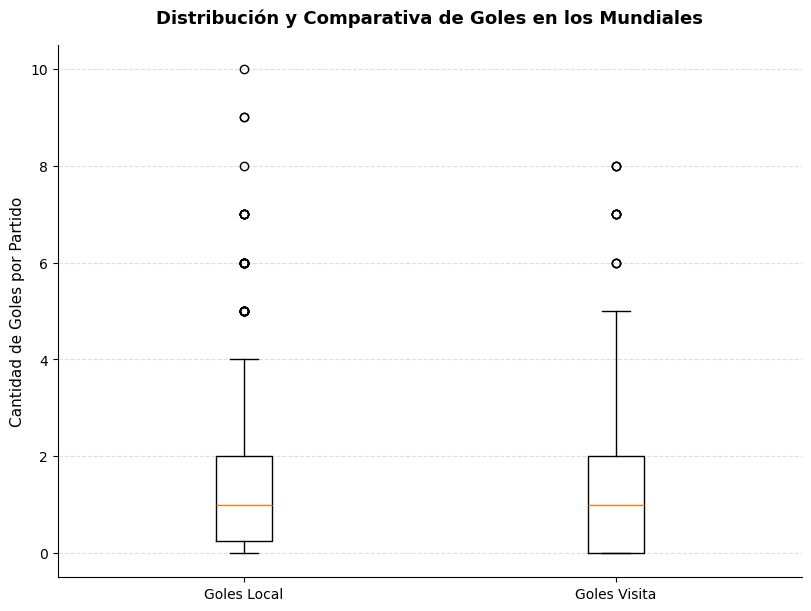

In [9]:
df_eda.outliers()

Por medio de estos gráficos de cajas (boxplot) podemos observar de manera visual lo que veíamos en la descripción.

Se observa como la mayoría de datos están entre 0 y 2 goles anotados; los goles locales se encuentra entre 0.25 y 2 aproximadamente, mientras que los goles de visita entre 0 y 2, además se observa que los outliers aparecen mas rápido con goles anotados, a diferencia de gol visita que hasta 6 goles anotados es que empiezan a aparecer los outliers.

#### 5. Goles Marcados

In [10]:
df_eda.goles_por_mundial()

,Sede(s),Año,Goles Anotados
3,Canada / Mexico / United States,2026,297
15,Qatar,2022,172
2,Brazil,2014,171
7,France,1998,171
16,Russia,2018,169
12,Japan / South Korea,2002,161
9,Germany,2006,147
18,Spain,1982,146
17,South Africa,2010,145
21,United States,1994,141


In [12]:
df_eda.goles_favor()

,Selección,Goles Anotados
0,Brazil,247
1,Germany,243
2,Argentina,171
3,France,152
4,Italy,128
...,...,...
81,El Salvador,1
82,Israel,1
83,China,0
84,Indonesia,0


Vemos que Alemania y Brasil son los dos países que mas goles han anotado y tienen mayor diferencia con respecto a los demás lugares del top ambos con mas de 240 goles y el tercer lugar es Argentina con 169, siendo esta una diferencia de mas de 70 goles.

#### Goles Recibidos

In [14]:
df_eda.goles_contra()

,Selección,Goles Recibidos
0,Germany,135
1,Brazil,112
2,Argentina,108
3,Mexico,104
4,France,89
...,...,...
81,Cape Verde,5
82,Iceland,5
83,Trinidad and Tobago,4
84,Israel,3


Observamos como es el mismo top 3 solamente que las distancias entre estas son mas cercanas, Alemania en esta ocación es la que está primera y se suma México dentro del top 5, esto nos dice que son selecciones que poseen muchas participaciones en los mundiales.

#### Diferencia de Goles

In [15]:
df_eda.diferencia_goles()

,Selección,Goles Anotados,Goles Recibidos,Diferencia Goles
8,Brazil,247,112,135
30,Germany,243,135,108
28,France,152,89,63
2,Argentina,171,108,63
41,Italy,128,77,51
...,...,...,...,...
10,Cameroon,22,47,-25
9,Bulgaria,22,53,-31
47,Mexico,72,104,-32
64,Saudi Arabia,15,49,-34


Brasil obtiene el primer puesto con el doble de puntos que el tercer puesto que es Francia, Alemania es segundo con un diferencia no tan marcada, esta tabla es importante ya que no refleja que tan buenas son las selecciones tanto defendiendo como atacando y que tanto estas avanzan en este torneo.

#### Victorias

In [16]:
df_eda.victorias()

,Selección,Cantidad de Victorias
0,Brazil,79
1,Germany,70
2,Argentina,54
3,Italy,45
4,France,45
...,...,...
60,Czech Republic,1
61,North Korea,1
62,Slovenia,1
63,Slovakia,1


Este gráfico nos muestra algo muy importante ya que entre mas victorias posee un equipo refleja no solo su participación sino que además muestra el desempeño que han tenido en este torneo, una selección con muchas victorias como Brasil o Alemania refleja que es una selección que no solo participa mucho sino que suele quedar entre las primeras posiciones.

#### Derrotas

In [17]:
df_eda.derrotas()

,Selección,Cantidad de Derrotas
0,Mexico,29
1,Argentina,24
2,Germany,24
3,South Korea,23
4,United States,22
...,...,...
81,Angola,1
82,Cuba,1
83,Cape Verde,1
84,Israel,1


Este apartado es importante porque también nos dice la constancia de estos equipos en cuantos a participaciones en el torneo y que tanto llegan a avanzar, observamos que México lidera el primer puesto, hecho que hace sentido con su aparición en los equipos que mas goles han encajado.

#### Empates

In [18]:
df_eda.empates()

,Selección,Cantidad de Empates
0,England,23
1,Germany,22
2,Italy,21
3,Brazil,20
4,Spain,18
...,...,...
70,Slovenia,1
71,Slovakia,1
72,Ukraine,1
73,Trinidad and Tobago,1


Observamos que el empate es el resultado menos frecuente en un partido, motivo por el cual vemos que no hay mucha distancia entre puesto y puesto.

#### Mundiales con mas Goles

In [19]:
df_eda.mas_gol_mundial()

,Sede(s),Año,Goles Anotados
0,Canada / Mexico / United States,2026,297
1,Qatar,2022,172
2,Brazil,2014,171
3,France,1998,171
4,Russia,2018,169
5,Japan / South Korea,2002,161
6,Germany,2006,147
7,Spain,1982,146
8,South Africa,2010,145
9,United States,1994,141


Esto nos da los mundiales con mayor cantidad de goles en la historia, observamos una apabuyante diferencia entre el primer puesto con el resto de la tabla ya que son mas de 120 goles de diferencia, además, observamos que la mayoría de mundiales en el top son de este siglo, lo cual refleja como el deporte ha evolucionado a lo largo de la historia.

#### Mundial con menos Goles

In [20]:
df_eda.menos_gol_mundial()

,Sede(s),Año,Goles Anotados
0,Italy,1934,70
1,Uruguay,1930,70
2,France,1938,84
3,Brazil,1950,88
4,England,1966,89
5,Chile,1962,89
6,Mexico,1970,95
7,Germany,1974,97
8,Argentina,1978,102
9,Italy,1990,115


Se nos muestra como justamente los mundiales con menos goles eran los primeros, esto nos da un reflejo tanto del deporte como del torneo en sí, ya que este ha sufrido cambios que han reflejado la evolución y aumento de dicha cantidad.

#### Cantidad de Veces que un País fue Sede

In [22]:
df_eda.veces_sede()

,País Sede,Veces Sede,Campeón(es) Coronado(s),Año(s)
9,Mexico,3,"Brazil, Argentina","1970, 1986, 2026"
6,Germany,2,"Germany, France","1974, 2006"
1,Brazil,2,"Uruguay, Germany","1950, 2014"
17,United States,2,Italy,"1994, 2026"
5,France,2,"Brazil, France","1938, 1998"
7,Italy,2,"Italy, Germany","1934, 1990"
0,Argentina,1,Argentina,1978
2,Canada,1,,2026
3,Chile,1,Brazil,1962
8,Japan,1,Brazil,2002


En este gráfico además de observar la cantidad de veces que un país fue sede y el año en el que fue, también se nos muestra cuales países han salido campeonas en dicha edición.

#### Desempeño Histórico

In [23]:
df_eda.ranking_mundial()

,Selección,Cantidad de Victorias,Cantidad de Empates,Cantidad de Derrotas,Goles Anotados,Goles Recibidos,Diferencia Goles,Puntos
0,Brazil,79,20,20,247,112,135,257
1,Germany,70,22,24,243,135,108,232
2,Argentina,54,17,24,171,108,63,179
3,Italy,45,21,17,128,77,51,156
4,France,45,14,21,152,89,63,149
...,...,...,...,...,...,...,...,...
81,Indonesia,0,0,1,0,6,-6,0
82,Panama,0,0,6,2,15,-13,0
83,Togo,0,0,3,1,6,-5,0
84,United Arab Emirates,0,0,3,2,11,-9,0


Por último obtenemos un ranking de desempeño de las selecciones a lo largo de la historia en los mundiales, se escogió el sistema actual de puntos para crear la lista, es decir:
- Victoria: 3 puntos
- Empate: 1 punto
- Derrota: 0 puntos

De esta manera se puede hacer de una manera clara cuales han sido históricamente las mejores selecciones en mundiales desde que su creación en 1930.